In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1) b. ii.

In [31]:
# Definir la matriz P1
P1 = np.array([
    [0.2, 0.5, 0.3],
    [0.3, 0.3, 0.4],
    [0.7, 0.2, 0.1]
])

# Elevar a la potencia 10
P1_pow_10 = np.linalg.matrix_power(P1, 10)

# Imprimir la matriz resultante
print(P1_pow_10)

[[0.37415071 0.34693778 0.27891151]
 [0.37415034 0.34693888 0.27891078]
 [0.37414741 0.34693998 0.27891261]]


### 2) a Matriz de transición

In [32]:
# Número total de estados (de 0 a 10)
n_states = 11

# Definimos probabilidades
p_lose = 0.53
p_win = 0.47

# Inicializamos la matriz P como matriz de ceros de tamaño 11x11
P = np.zeros((n_states, n_states))

# Para cada estado intermedio (de 1 a 9)
for i in range(1, n_states - 1):
     P[i, i - 1] = p_lose
     P[i, i + 1] = p_win

# Estados absorbentes
P[0, 0] = 1.0
P[10, 10] = 1.0

print(P)

[[1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.53 0.   0.47 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.53 0.   0.47 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.53 0.   0.47 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.53 0.   0.47 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.53 0.   0.47 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.53 0.   0.47 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.53 0.   0.47 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.53 0.   0.47 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.53 0.   0.47]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]]


### 2) b resolviendo sistema de ecuaciones lineales

In [33]:
# Recompensas: -10 en estado 0 (pierde), +10 en estado 10 (gana), 0 en los demás
n= 11
r = np.zeros(n)
r[0] = -10
r[10] = 10

# Crear sistema de ecuaciones para estados intermedios: V(1) a V(9)
A = np.zeros((n - 2, n - 2))  # matriz de coeficientes
b = np.zeros(n - 2)          # vector del lado derecho

for i in range(1, n - 1):  # estados de 1 a 9
    row = i - 1
    A[row, row] = 1
    if i - 1 > 0:
        A[row, row - 1] = -p_lose
    else:
        b[row] += p_lose * r[0]  # borde izquierdo con V(0)

    if i + 1 < 10:
        A[row, row + 1] = -p_win
    else:
        b[row] += p_win * r[10]  # borde derecho con V(10)

# Resolver el sistema lineal: A * x = b
V_inner = np.linalg.solve(A, b)

# Construir el vector completo de V(i)
V = np.zeros(n)
V[0] = r[0]
V[1:10] = V_inner
V[10] = r[10]

# Mostrar los resultados
for i in range(n):
    print(f"V({i}) = {V[i]:.4f}")

V(0) = -10.0000
V(1) = -8.9018
V(2) = -7.6634
V(3) = -6.2670
V(4) = -4.6922
V(5) = -2.9164
V(6) = -0.9140
V(7) = 1.3442
V(8) = 3.8905
V(9) = 6.7620
V(10) = 10.0000


### 2) d resolviendo para n=100

Mínima cantidad de fichas necesarias para que la ganancia esperada sea positiva: 95


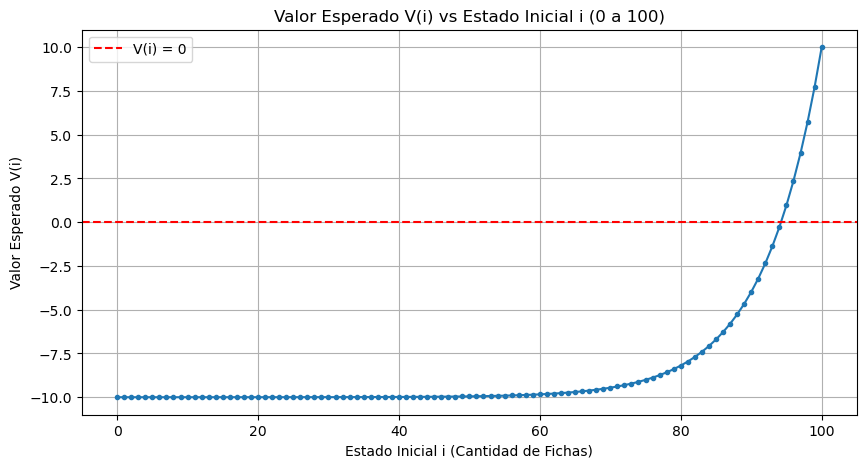

In [34]:


# Número de estados: de 0 a 100
n = 101
p_lose = 0.53
p_win = 0.47

# Recompensas: -10 en estado 0 (pierde), +10 en estado 100 (gana), 0 en los demás
r = np.zeros(n)
r[0] = -10
r[100] = 10

# Crear sistema de ecuaciones para estados intermedios: V(1) a V(99)
A = np.zeros((n - 2, n - 2))  # matriz de coeficientes
b = np.zeros(n - 2)          # vector del lado derecho

for i in range(1, n - 1):  # estados de 1 a 99
    row = i - 1
    A[row, row] = 1
    if i - 1 > 0:
        A[row, row - 1] = -p_lose
    else:
        b[row] += p_lose * r[0]  # borde izquierdo con V(0)

    if i + 1 < n - 1:
        A[row, row + 1] = -p_win
    else:
        b[row] += p_win * r[100]  # borde derecho con V(100)

# Resolver el sistema lineal: A * x = b
V_inner = np.linalg.solve(A, b)

# Construir el vector completo de V(i)
V = np.zeros(n)
V[0] = r[0]
V[1:100] = V_inner
V[100] = r[100]

# Encontrar la mínima cantidad de fichas necesarias para que V(i) > 0
min_fichas_con_ganancia_esperada_positiva = next(i for i in range(n) if V[i] > 0)

# Mostrar resultado
print(f"Mínima cantidad de fichas necesarias para que la ganancia esperada sea positiva: {min_fichas_con_ganancia_esperada_positiva}")

# Graficar V(i)
plt.figure(figsize=(10, 5))
plt.plot(range(n), V, marker='o', markersize=3)
plt.axhline(y=0, color='red', linestyle='--', label='V(i) = 0')
plt.title('Valor Esperado V(i) vs Estado Inicial i (0 a 100)')
plt.xlabel('Estado Inicial i (Cantidad de Fichas)')
plt.ylabel('Valor Esperado V(i)')
plt.grid(True)
plt.legend()
plt.show()

### Probelma 3

In [35]:
# Orden de estados: [AA, DD, AD, DA]
P = np.array([
    [0.8, 0.0, 0.2, 0.0],
    [0.0, 0.9, 0.0, 0.1],
    [0.5, 0.0, 0.5, 0.0],
    [0.7, 0.0, 0.3, 0.0]
])

# Estado inicial: estuvo al día las últimas dos semanas → DD
pi_0 = np.array([0, 1, 0, 0])

# Calculamos distribución en 2 semanas: π_2 = π_0 · P^2
pi_2 = pi_0 @ P @ P

# Estados con semana final atrasada: AA y DA → índices 0 y 3
prob_atrasado = pi_2[0] + pi_2[3]

print(f"Probabilidad de estar atrasado en dos semanas: {prob_atrasado:.4f}")

Probabilidad de estar atrasado en dos semanas: 0.1600


item d

π_∞ = π_0 · P^∞ ≈ [0.7143 0.     0.2857 0.    ]
Porcentaje de semanas al día: 28.57%
Porcentaje de semanas atrasado: 71.43%


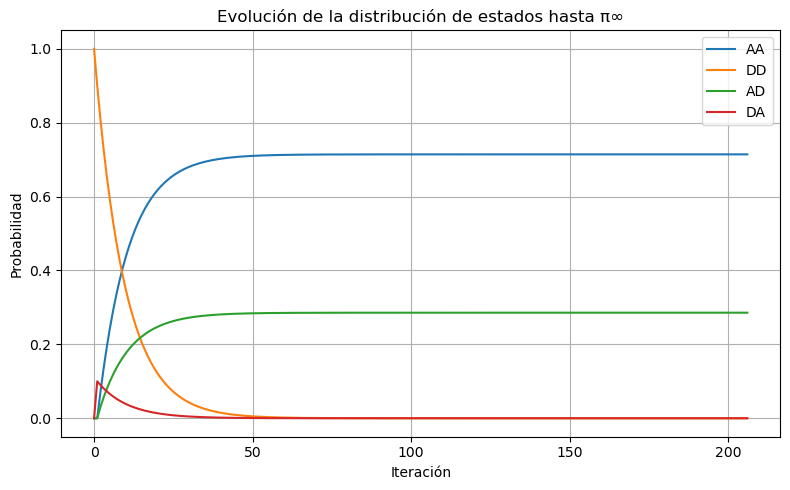

In [36]:
# Iteramos hasta convergencia para obtener π∞ y guardar historia
pi_t = pi_0.copy()
tol = 1e-10
max_iter = 10000
history = [pi_t.copy()]

for _ in range(max_iter):
    pi_next = pi_t @ P
    history.append(pi_next)
    if np.linalg.norm(pi_next - pi_t, ord=1) < tol:
        break
    pi_t = pi_next

pi_inf = pi_t

# Estados donde el estudiante está al día: DD (índice 1) y AD (índice 2)
prob_al_dia = pi_inf[1] + pi_inf[2]
prob_atrasado = pi_inf[0] + pi_inf[3]

# Mostrar resultados
print("π_∞ = π_0 · P^∞ ≈", np.round(pi_inf, 4))
print(f"Porcentaje de semanas al día: {prob_al_dia:.2%}")
print(f"Porcentaje de semanas atrasado: {prob_atrasado:.2%}")

# ---- GRAFICAR LA EVOLUCIÓN ----
history_array = np.array(history)
estados = ['AA', 'DD', 'AD', 'DA']

plt.figure(figsize=(8, 5))
for i, estado in enumerate(estados):
    plt.plot(history_array[:, i], label=estado)

plt.xlabel('Iteración')
plt.ylabel('Probabilidad')
plt.title('Evolución de la distribución de estados hasta π∞')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### ejericcio 4 punto d

In [37]:
M = np.array([
    [38240, 166.52, 155.94, 120.06, 17.48],
    [179.6, 20980, 118.8, 90.0, 11.6],
    [211.98, 110.45, 14595.19, 90.06, 12.32],
    [120.06, 90.0, 90.06, 4246.8, 4.88],
    [3.12, 16.63, 9.46, 4.88, 5177.72]
])

# Normalización por columnas
P = M / M.sum(axis=1, keepdims=True)

# Orden de empresas
empresas = ['Claro', 'Movistar', 'Tigo', 'WOM', 'Otras']

# Distribución actual (en millones de usuarios)
pi_0_millones = np.array([38.7, 21.38, 15.02, 4.67, 5.23])
pi_0 = pi_0_millones / pi_0_millones.sum()

# Evolución en 8 trimestres (2 años)
P_n = np.linalg.matrix_power(P, 8)
pi_8 = pi_0 @ P_n

# Mostrar resultados
for empresa, actual, futuro in zip(empresas, pi_0, pi_8):
    print(f"{empresa:10}: Actual = {actual*100:.2f}%, En 2 años = {futuro*100:.2f}%")

Claro     : Actual = 45.53%, En 2 años = 46.02%
Movistar  : Actual = 25.15%, En 2 años = 25.02%
Tigo      : Actual = 17.67%, En 2 años = 17.26%
WOM       : Actual = 5.49%, En 2 años = 5.43%
Otras     : Actual = 6.15%, En 2 años = 6.26%


### punto d

In [38]:
# Matriz de flujos reales (en miles de usuarios, incluyendo retención)
M = np.array([
    [38240, 166.52, 155.94, 120.06, 17.48],
    [179.6, 20980, 118.8, 90.0, 11.6],
    [211.98, 110.45, 14595.19, 90.06, 12.32],
    [120.06, 90.0, 90.06, 4246.8, 4.88],
    [3.12, 16.63, 9.46, 4.88, 5177.72]
])

# ✅ Normalizamos por FILAS para convertir a matriz de transición
P = M / M.sum(axis=1, keepdims=True)

# Estado inicial: distribución actual del mercado en millones de usuarios
pi_0_millones = np.array([38.7, 21.38, 15.02, 4.67, 5.23])
pi_0 = pi_0_millones / pi_0_millones.sum()

# Iteración para encontrar el estado estacionario π_∞
pi_t = pi_0.copy()
tol = 1e-10
max_iter = 10000

for _ in range(max_iter):
    pi_next = pi_t @ P
    if np.linalg.norm(pi_next - pi_t, ord=1) < tol:
        break
    pi_t = pi_next

pi_inf = pi_t

# Mostrar resultados
for empresa, participacion in zip(['Claro', 'Movistar', 'Tigo', 'WOM', 'Otras'], pi_inf):
    print(f"{empresa:10}: Participación en equilibrio = {participacion*100:.2f}%")

Claro     : Participación en equilibrio = 47.30%
Movistar  : Participación en equilibrio = 23.87%
Tigo      : Participación en equilibrio = 15.58%
WOM       : Participación en equilibrio = 5.20%
Otras     : Participación en equilibrio = 8.05%


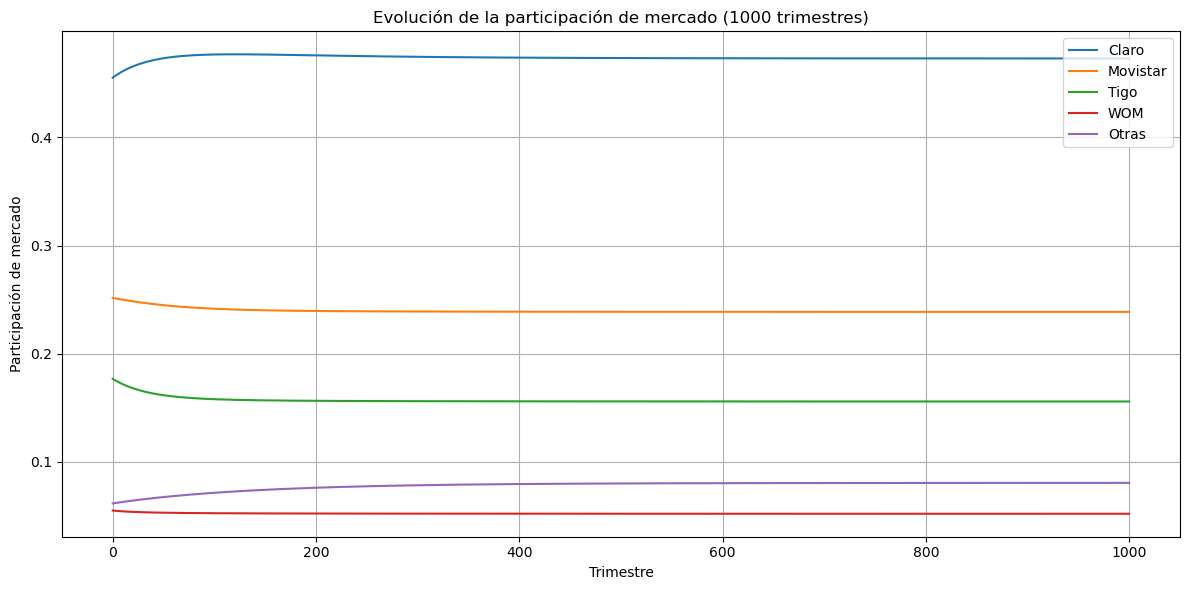

In [39]:
# Simular 1000 trimestres
num_iterations = 1000
history = [pi_0]

for _ in range(num_iterations):
    pi_next = history[-1] @ P
    history.append(pi_next)

# Convertimos a DataFrame para análisis o gráficos
history_array = np.array(history)
empresas = ['Claro', 'Movistar', 'Tigo', 'WOM', 'Otras']
df_evolution = pd.DataFrame(history_array, columns=empresas)
df_evolution['Trimestre'] = df_evolution.index

# Graficar evolución
plt.figure(figsize=(12, 6))
for empresa in empresas:
    plt.plot(df_evolution['Trimestre'], df_evolution[empresa], label=empresa)

plt.xlabel('Trimestre')
plt.ylabel('Participación de mercado')
plt.title('Evolución de la participación de mercado (1000 trimestres)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()